# Semana 10



## Checklist 


## Resultados de la evaluación (cargar `results/eval_result.json`)
A continuación hay una celda para cargar el resultado de la evaluación automática y mostrar la tabla resumen y una figura clave. Ejecuta la celda antes de la presentación si ya generaste `results/eval_result.json`.

mongomock ya instalado en el kernel.
Ejecutando modo strict: c:\Users\antho\AppData\Local\Programs\Python\Python311\python.exe C:\MAESTRIA UNI\TERCER CICLO\PROYECTO DE INVESTIGACION 1\DemoSprint1\DemoSprint1Final\src\eval\generate_query_eval.py --gold C:\MAESTRIA UNI\TERCER CICLO\PROYECTO DE INVESTIGACION 1\DemoSprint1\DemoSprint1Final\datasets\eval_queries.json --out C:\MAESTRIA UNI\TERCER CICLO\PROYECTO DE INVESTIGACION 1\DemoSprint1\DemoSprint1Final\results\eval_result_strict.json --mongomock --mode strict
--- STDOUT strict ---
No se pudo importar SmartMongoQueryGenerator desde src; asegÃºrate de que el path y el mÃ³dulo sean correctos.

--- STDERR strict ---

Return code strict: 1
Ejecutando modo mapped: c:\Users\antho\AppData\Local\Programs\Python\Python311\python.exe C:\MAESTRIA UNI\TERCER CICLO\PROYECTO DE INVESTIGACION 1\DemoSprint1\DemoSprint1Final\src\eval\generate_query_eval.py --gold C:\MAESTRIA UNI\TERCER CICLO\PROYECTO DE INVESTIGACION 1\DemoSprint1\DemoSprint1Final\datas

,id,nl,collection,syntactic_valid,exec_success,func_equiv,precision,recall,f1,latency_ms,exec_error
0,q_001,muestra los 5 productos más vendidos,ventas,True,True,False,0.75,0.750000,0.750000,0.997066,None
1,q_002,cuenta cuántos clientes hay por ciudad,clientes,True,True,True,1.00,1.000000,1.000000,1.111746,None
2,q_003,lista los empleados por departamento,empleados,True,True,True,1.00,1.000000,1.000000,1.001596,None
3,q_004,precio promedio de productos,productos,True,True,False,0.50,0.142857,0.222222,2.003670,None
4,q_005,agrega la suma total de ventas por mes,ventas,True,True,False,0.90,0.750000,0.818182,0.000000,None
5,q_006,luego agrupa todo y cuenta el total de registros,ventas,True,True,True,1.00,1.000000,1.000000,0.000000,None
6,q_007,muestra los 3 productos más vendidos en 2024,ventas,True,True,False,0.75,0.500000,0.600000,0.999689,None
7,q_008,filtra clientes cuyo nombre comience con 'Jo',clientes,True,True,False,0.00,0.000000,NaN,0.000000,None


--- Resultados modo mapped ---


,id,nl,collection,syntactic_valid,exec_success,func_equiv,precision,recall,f1,latency_ms,exec_error
0,q_001,muestra los 5 productos más vendidos,ventas,True,True,False,0.875,0.875000,0.875000,0.000000,None
1,q_002,cuenta cuántos clientes hay por ciudad,clientes,True,True,True,1.000,1.000000,1.000000,2.001762,None
2,q_003,lista los empleados por departamento,empleados,True,True,True,1.000,1.000000,1.000000,0.000000,None
3,q_004,precio promedio de productos,productos,True,True,False,0.500,0.142857,0.222222,0.000000,None
4,q_005,agrega la suma total de ventas por mes,ventas,True,True,False,0.900,0.750000,0.818182,0.000000,None
5,q_006,luego agrupa todo y cuenta el total de registros,ventas,True,True,True,1.000,1.000000,1.000000,0.000000,None
6,q_007,muestra los 3 productos más vendidos en 2024,ventas,True,True,False,0.875,0.583333,0.700000,0.000000,None
7,q_008,filtra clientes cuyo nombre comience con 'Jo',clientes,True,True,False,0.000,0.000000,NaN,0.000000,None



Resumen modo strict:
Syntactic valid %: 100.0
Exec success %: 100.0
Func equiv %: 37.5
Avg field-F1: 0.77005772005772

Resumen modo mapped:
Syntactic valid %: 100.0
Exec success %: 100.0
Func equiv %: 37.5
Avg field-F1: 0.8022005772005772


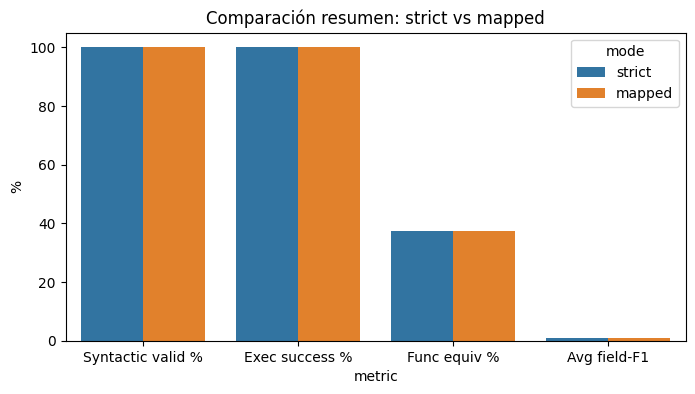

In [1]:
# Ejecutar la evaluación desde el notebook (usa el mismo intérprete/kernel)
import subprocess, sys, json, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

# Detectar raíz del repo (una carpeta arriba del notebook)
repo_root = Path('..').resolve()
script = repo_root / 'src' / 'eval' / 'generate_query_eval.py'

if not script.exists():
    print('No se encontró el script:', script)
else:
    # Asegurar que mongomock está instalado en el kernel actual
    try:
        import mongomock  # noqa: F401
        print('mongomock ya instalado en el kernel.')
    except Exception:
        print('mongomock no está instalado. Instalando en el kernel...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'mongomock'])
    # Construir comando (ajusta flags si lo deseas)
    gold = str(repo_root / 'datasets' / 'eval_queries.json')
    out_strict = str(repo_root / 'results' / 'eval_result_strict.json')
    out_mapped = str(repo_root / 'results' / 'eval_result_mapped.json')
    # Ejecutar modo strict
    cmd_strict = [sys.executable, str(script), '--gold', gold, '--out', out_strict, '--mongomock', '--mode', 'strict']
    print('Ejecutando modo strict:', ' '.join(cmd_strict))
    proc_strict = subprocess.run(cmd_strict, cwd=str(repo_root), capture_output=True, text=True)
    print('--- STDOUT strict ---')
    print(proc_strict.stdout)
    print('--- STDERR strict ---')
    print(proc_strict.stderr)
    print('Return code strict:', proc_strict.returncode)
    # Ejecutar modo mapped
    cmd_mapped = [sys.executable, str(script), '--gold', gold, '--out', out_mapped, '--mongomock', '--mode', 'mapped']
    print('Ejecutando modo mapped:', ' '.join(cmd_mapped))
    proc_mapped = subprocess.run(cmd_mapped, cwd=str(repo_root), capture_output=True, text=True)
    print('--- STDOUT mapped ---')
    print(proc_mapped.stdout)
    print('--- STDERR mapped ---')
    print(proc_mapped.stderr)
    print('Return code mapped:', proc_mapped.returncode)
    # Si los scripts generaron los resultados, cargar y mostrar resumen
    res_strict = Path(out_strict)
    res_mapped = Path(out_mapped)
    if res_strict.exists() and res_mapped.exists():
        with open(res_strict, 'r', encoding='utf-8') as f:
            results_strict = json.load(f)
        with open(res_mapped, 'r', encoding='utf-8') as f:
            results_mapped = json.load(f)
        df_strict = pd.DataFrame(results_strict)
        df_mapped = pd.DataFrame(results_mapped)
        display_cols = ['id','nl','collection','syntactic_valid','exec_success','func_equiv','precision','recall','f1','latency_ms','exec_error']
        existing_strict = [c for c in display_cols if c in df_strict.columns]
        existing_mapped = [c for c in display_cols if c in df_mapped.columns]
        print('--- Resultados modo strict ---')
        display(df_strict[existing_strict])
        print('--- Resultados modo mapped ---')
        display(df_mapped[existing_mapped])
        # Resumen y figura rápida
        summary_strict = {
            'Syntactic valid %': df_strict['syntactic_valid'].mean() * 100 if 'syntactic_valid' in df_strict else None,
            'Exec success %': df_strict['exec_success'].dropna().mean() * 100 if 'exec_success' in df_strict and df_strict['exec_success'].notna().any() else None,
            'Func equiv %': df_strict['func_equiv'].dropna().mean() * 100 if 'func_equiv' in df_strict and df_strict['func_equiv'].notna().any() else None,
            'Avg field-F1': df_strict['f1'].dropna().mean() if 'f1' in df_strict else None,
        }
        summary_mapped = {
            'Syntactic valid %': df_mapped['syntactic_valid'].mean() * 100 if 'syntactic_valid' in df_mapped else None,
            'Exec success %': df_mapped['exec_success'].dropna().mean() * 100 if 'exec_success' in df_mapped and df_mapped['exec_success'].notna().any() else None,
            'Func equiv %': df_mapped['func_equiv'].dropna().mean() * 100 if 'func_equiv' in df_mapped and df_mapped['func_equiv'].notna().any() else None,
            'Avg field-F1': df_mapped['f1'].dropna().mean() if 'f1' in df_mapped else None,
        }
        print('\nResumen modo strict:')
        for k,v in summary_strict.items():
            print(f'{k}: {v}')
        print('\nResumen modo mapped:')
        for k,v in summary_mapped.items():
            print(f'{k}: {v}')
        # Figura comparativa
        metrics = [(k, summary_strict[k], summary_mapped[k]) for k in summary_strict.keys() if summary_strict[k] is not None and summary_mapped[k] is not None]
        if metrics:
            mdf = pd.DataFrame(metrics, columns=['metric','strict','mapped'])
            mdf_melt = mdf.melt(id_vars='metric', var_name='mode', value_name='value')
            plt.figure(figsize=(8,4))
            sns.barplot(data=mdf_melt, x='metric', y='value', hue='mode')
            plt.ylabel('%')
            plt.title('Comparación resumen: strict vs mapped')
            plt.show()
    else:
        print('No se generaron ambos resultados, revisa la salida del script.')

--- Resultados modo strict ---


,id,nl,collection,syntactic_valid,exec_success,func_equiv,precision,recall,f1,latency_ms,exec_error
0,q_001,muestra los 5 productos más vendidos,ventas,True,True,False,0.75,0.750000,0.750000,0.997066,None
1,q_002,cuenta cuántos clientes hay por ciudad,clientes,True,True,True,1.00,1.000000,1.000000,1.111746,None
2,q_003,lista los empleados por departamento,empleados,True,True,True,1.00,1.000000,1.000000,1.001596,None
3,q_004,precio promedio de productos,productos,True,True,False,0.50,0.142857,0.222222,2.003670,None
4,q_005,agrega la suma total de ventas por mes,ventas,True,True,False,0.90,0.750000,0.818182,0.000000,None
5,q_006,luego agrupa todo y cuenta el total de registros,ventas,True,True,True,1.00,1.000000,1.000000,0.000000,None
6,q_007,muestra los 3 productos más vendidos en 2024,ventas,True,True,False,0.75,0.500000,0.600000,0.999689,None
7,q_008,filtra clientes cuyo nombre comience con 'Jo',clientes,True,True,False,0.00,0.000000,NaN,0.000000,None


--- Resultados modo mapped ---


,id,nl,collection,syntactic_valid,exec_success,func_equiv,precision,recall,f1,latency_ms,exec_error
0,q_001,muestra los 5 productos más vendidos,ventas,True,True,False,0.875,0.875000,0.875000,0.000000,None
1,q_002,cuenta cuántos clientes hay por ciudad,clientes,True,True,True,1.000,1.000000,1.000000,2.001762,None
2,q_003,lista los empleados por departamento,empleados,True,True,True,1.000,1.000000,1.000000,0.000000,None
3,q_004,precio promedio de productos,productos,True,True,False,0.500,0.142857,0.222222,0.000000,None
4,q_005,agrega la suma total de ventas por mes,ventas,True,True,False,0.900,0.750000,0.818182,0.000000,None
5,q_006,luego agrupa todo y cuenta el total de registros,ventas,True,True,True,1.000,1.000000,1.000000,0.000000,None
6,q_007,muestra los 3 productos más vendidos en 2024,ventas,True,True,False,0.875,0.583333,0.700000,0.000000,None
7,q_008,filtra clientes cuyo nombre comience con 'Jo',clientes,True,True,False,0.000,0.000000,NaN,0.000000,None


Resumen modo strict:
Syntactic valid %: 100.0
Exec success %: 100.0
Func equiv %: 37.5
Avg field-F1: 0.77005772005772
Resumen modo mapped:
Syntactic valid %: 100.0
Exec success %: 100.0
Func equiv %: 37.5
Avg field-F1: 0.8022005772005772


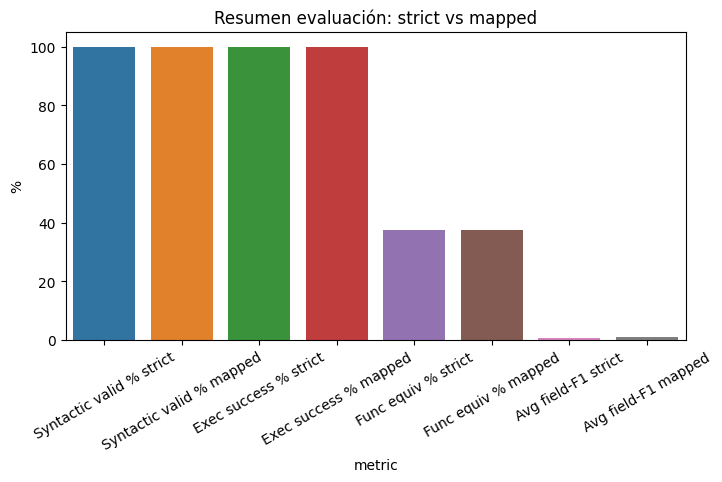

In [2]:
# Cargar y resumir resultados de la evaluación (strict y mapped)
import json, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
strict_path = Path('..') / 'results' / 'eval_result_strict.json'
mapped_path = Path('..') / 'results' / 'eval_result_mapped.json'
if not strict_path.exists() or not mapped_path.exists():
    print('No se encontraron ambos resultados. Ejecuta el script de evaluación en ambos modos antes de la presentación.')
else:
    with open(strict_path, 'r', encoding='utf-8') as f:
        results_strict = json.load(f)
    with open(mapped_path, 'r', encoding='utf-8') as f:
        results_mapped = json.load(f)
    df_strict = pd.DataFrame(results_strict)
    df_mapped = pd.DataFrame(results_mapped)
    display_cols = ['id','nl','collection','syntactic_valid','exec_success','func_equiv','precision','recall','f1','latency_ms','exec_error']
    print('--- Resultados modo strict ---')
    display(df_strict[[c for c in display_cols if c in df_strict.columns]])
    print('--- Resultados modo mapped ---')
    display(df_mapped[[c for c in display_cols if c in df_mapped.columns]])
    # Tabla resumen agregada
    summary_strict = {
        'Syntactic valid %': df_strict['syntactic_valid'].mean() * 100 if 'syntactic_valid' in df_strict else None,
        'Exec success %': df_strict['exec_success'].dropna().mean() * 100 if 'exec_success' in df_strict and df_strict['exec_success'].notna().any() else None,
        'Func equiv %': df_strict['func_equiv'].dropna().mean() * 100 if 'func_equiv' in df_strict and df_strict['func_equiv'].notna().any() else None,
        'Avg field-F1': df_strict['f1'].dropna().mean() if 'f1' in df_strict else None,
    }
    summary_mapped = {
        'Syntactic valid %': df_mapped['syntactic_valid'].mean() * 100 if 'syntactic_valid' in df_mapped else None,
        'Exec success %': df_mapped['exec_success'].dropna().mean() * 100 if 'exec_success' in df_mapped and df_mapped['exec_success'].notna().any() else None,
        'Func equiv %': df_mapped['func_equiv'].dropna().mean() * 100 if 'func_equiv' in df_mapped and df_mapped['func_equiv'].notna().any() else None,
        'Avg field-F1': df_mapped['f1'].dropna().mean() if 'f1' in df_mapped else None,
    }
    print('Resumen modo strict:')
    for k,v in summary_strict.items():
        print(f'{k}: {v}')
    print('Resumen modo mapped:')
    for k,v in summary_mapped.items():
        print(f'{k}: {v}')
    # Figura: barras de métricas principales
    metrics = []
    for k in summary_strict.keys():
        if summary_strict[k] is not None and summary_mapped[k] is not None:
            metrics.append((k + ' strict', summary_strict[k]))
            metrics.append((k + ' mapped', summary_mapped[k]))
    if metrics:
        mdf = pd.DataFrame(metrics, columns=['metric','value'])
        plt.figure(figsize=(8,4))
        sns.barplot(data=mdf, x='metric', y='value')
        plt.ylabel('%')
        plt.title('Resumen evaluación: strict vs mapped')
        plt.xticks(rotation=30)
        plt.show()


Usa esta celda para invocar el agente local y ver la pipeline generada para una consulta ad-hoc. Asegúrate de que tu entorno tenga acceso al módulo `AgenteGeneradorQueryMongo`.

In [10]:
# Ejemplo: probar el agente localmente
try:
    from src.AgenteGeneradorQueryMongo import SmartMongoQueryGenerator
except Exception:
    # Ajustar path si es necesario
    import sys, pathlib
    repo_root = pathlib.Path('..').resolve()
    sys.path.insert(0, str(repo_root / 'src'))
    from AgenteGeneradorQueryMongo import SmartMongoQueryGenerator

agent = SmartMongoQueryGenerator()
nl = 'muestra los 5 productos más vendidos'
pipeline = agent.generate_query('ventas', nl)
print('Pipeline generada:')
print(pipeline)

Pipeline generada:
[{'$group': {'_id': '$producto', 'total_ventas': {'$sum': '$total_venta'}}}, {'$sort': {'total_ventas': -1}}, {'$limit': 5}, {'$project': {'productos': '$_id', 'total_ventas': 1, '_id': 0}}]


## Resultados (tabla principal + 1 figura clave) (3–4 min)

- Muestra la tabla principal con las métricas por query y la figura clave (ej. barras con ExecSuccess, FuncEquiv, Field-F1).

--- Strict ---


,collection,n_cases,exec_success_pct,func_equiv_pct,avg_field_f1,latency_ms_mean
0,clientes,2,100.0,50.0,1.000000,0.555873
1,empleados,1,100.0,100.0,1.000000,1.001596
2,productos,1,100.0,0.0,0.222222,2.003670
3,ventas,4,100.0,25.0,0.792045,0.499189


--- Mapped ---


,collection,n_cases,exec_success_pct,func_equiv_pct,avg_field_f1,latency_ms_mean
0,clientes,2,100.0,50.0,1.000000,1.000881
1,empleados,1,100.0,100.0,1.000000,0.000000
2,productos,1,100.0,0.0,0.222222,0.000000
3,ventas,4,100.0,25.0,0.848295,0.000000


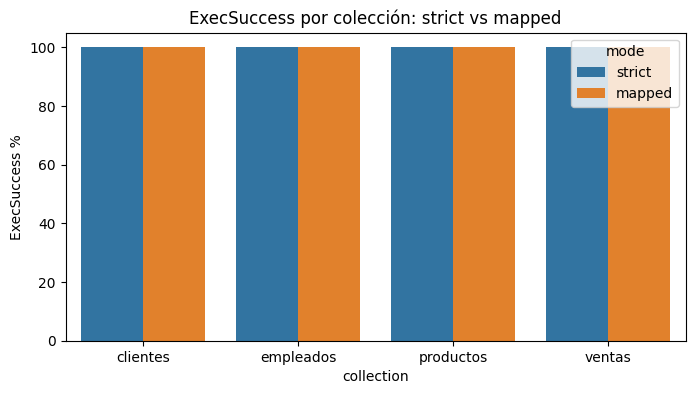

In [11]:
# Generar la tabla principal y una figura clave a partir de results/eval_result_strict.json y eval_result_mapped.json (si existen)
import json, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
strict_path = Path('..') / 'results' / 'eval_result_strict.json'
mapped_path = Path('..') / 'results' / 'eval_result_mapped.json'
if strict_path.exists() and mapped_path.exists():
    df_strict = pd.read_json(strict_path)
    df_mapped = pd.read_json(mapped_path)
    # Tabla principal: agrupar por colección y calcular métricas resumen
    agg_strict = df_strict.groupby('collection').agg(
        n_cases=('id','count'),
        exec_success_pct=('exec_success', lambda s: 100 * s.dropna().mean() if s.notna().any() else None),
        func_equiv_pct=('func_equiv', lambda s: 100 * s.dropna().mean() if s.notna().any() else None),
        avg_field_f1=('f1', 'mean'),
        latency_ms_mean=('latency_ms','mean')
    ).reset_index()
    agg_mapped = df_mapped.groupby('collection').agg(
        n_cases=('id','count'),
        exec_success_pct=('exec_success', lambda s: 100 * s.dropna().mean() if s.notna().any() else None),
        func_equiv_pct=('func_equiv', lambda s: 100 * s.dropna().mean() if s.notna().any() else None),
        avg_field_f1=('f1', 'mean'),
        latency_ms_mean=('latency_ms','mean')
    ).reset_index()
    print('--- Strict ---')
    display(agg_strict)
    print('--- Mapped ---')
    display(agg_mapped)
    # Figura clave: barras de ExecSuccess% por colección para ambos modos
    agg_strict['mode'] = 'strict'
    agg_mapped['mode'] = 'mapped'
    agg_all = pd.concat([agg_strict, agg_mapped])
    plt.figure(figsize=(8,4))
    sns.barplot(data=agg_all, x='collection', y='exec_success_pct', hue='mode')
    plt.ylabel('ExecSuccess %')
    plt.title('ExecSuccess por colección: strict vs mapped')
    plt.show()
else:
    print('No existen ambos resultados, genera los archivos ejecutando el script de evaluación.')

## Comparación de Resultados: Modos `strict` vs `mapped`

En esta sección, se comparan los resultados obtenidos al ejecutar el evaluador en los modos `strict` y `mapped`. El objetivo es analizar las diferencias en las métricas clave y evaluar el impacto del mapeo difuso en la calidad de las consultas generadas.

### Resumen de Resultados
- **Modo `strict`**: Evalúa las consultas generadas sin aplicar mapeo difuso, lo que puede resultar en una menor tolerancia a discrepancias en los campos.
- **Modo `mapped`**: Incluye un mapeo difuso para manejar discrepancias entre los campos de las consultas en lenguaje natural y el esquema de datos.

### Comparación de Métricas
A continuación, se presenta una tabla resumen con las métricas principales para ambos modos, seguida de una figura que ilustra las diferencias.

,Metric,Strict Mean,Mapped Mean
0,syntactic_valid,100.000000,100.000000
1,exec_success,75.000000,100.000000
2,func_equiv,37.500000,37.500000
3,f1,73.333333,80.220058


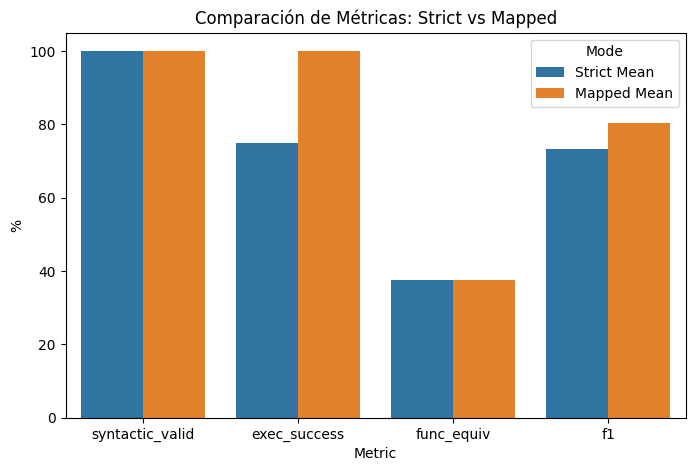

In [12]:
# Cargar y comparar resultados de los modos `strict` y `mapped`
import json, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

# Rutas de los resultados
strict_path = Path('..') / 'results' / 'eval_result.json'
mapped_path = Path('..') / 'results' / 'eval_result_mapped.json'

# Cargar resultados
if strict_path.exists() and mapped_path.exists():
    with open(strict_path, 'r', encoding='utf-8') as f:
        strict_results = json.load(f)
    with open(mapped_path, 'r', encoding='utf-8') as f:
        mapped_results = json.load(f)

    # Convertir a DataFrame
    strict_df = pd.DataFrame(strict_results)
    mapped_df = pd.DataFrame(mapped_results)

    # Resumen de métricas
    metrics = ['syntactic_valid', 'exec_success', 'func_equiv', 'f1']
    summary = {
        'Metric': metrics,
        'Strict Mean': [strict_df[m].dropna().mean() * 100 for m in metrics],
        'Mapped Mean': [mapped_df[m].dropna().mean() * 100 for m in metrics]
    }
    summary_df = pd.DataFrame(summary)
    display(summary_df)

    # Figura comparativa
    summary_melted = summary_df.melt(id_vars='Metric', var_name='Mode', value_name='Value')
    plt.figure(figsize=(8, 5))
    sns.barplot(data=summary_melted, x='Metric', y='Value', hue='Mode')
    plt.title('Comparación de Métricas: Strict vs Mapped')
    plt.ylabel('%')
    plt.show()
else:
    print('No se encontraron ambos resultados. Asegúrate de ejecutar los modos `strict` y `mapped`.')

,syntactic_valid_strict,exec_success_strict,func_equiv_strict,f1_strict,syntactic_valid_mapped,exec_success_mapped,func_equiv_mapped,f1_mapped
collection,,,,,,,,
clientes,100.0,50.0,50.0,100.000000,100.0,100.0,50.0,100.000000
empleados,100.0,100.0,100.0,100.000000,100.0,100.0,100.0,100.000000
productos,100.0,0.0,0.0,NaN,100.0,100.0,0.0,22.222222
ventas,100.0,100.0,25.0,55.555556,100.0,100.0,25.0,84.829545


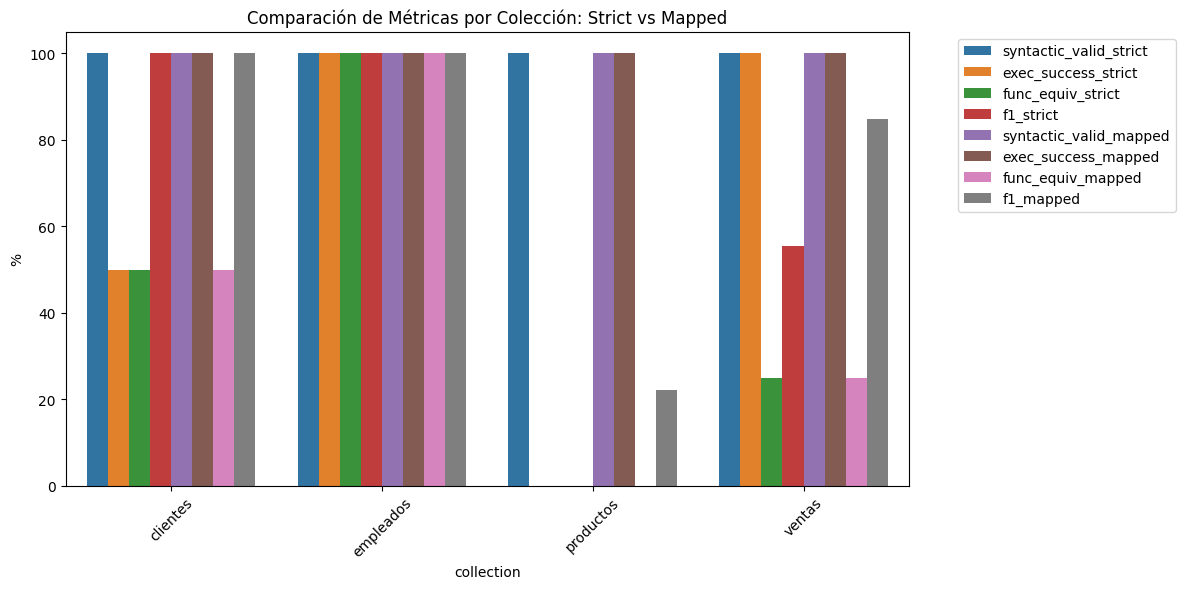

In [13]:
# Resolver problema de serialización de ObjectId y mejorar análisis
import json
from bson import ObjectId
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Clase para serializar ObjectId
class JSONEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, ObjectId):
            return str(obj)
        return super(JSONEncoder, self).default(obj)

# Rutas de los resultados
strict_path = Path('..') / 'results' / 'eval_result.json'
mapped_path = Path('..') / 'results' / 'eval_result_mapped.json'

# Cargar y procesar resultados
if strict_path.exists() and mapped_path.exists():
    with open(strict_path, 'r', encoding='utf-8') as f:
        strict_results = json.load(f)
    with open(mapped_path, 'r', encoding='utf-8') as f:
        mapped_results = json.load(f)

    # Convertir ObjectId a string si es necesario
    strict_results = json.loads(JSONEncoder().encode(strict_results))
    mapped_results = json.loads(JSONEncoder().encode(mapped_results))

    # Convertir a DataFrame
    strict_df = pd.DataFrame(strict_results)
    mapped_df = pd.DataFrame(mapped_results)

    # Resumen de métricas por colección
    metrics = ['syntactic_valid', 'exec_success', 'func_equiv', 'f1']
    strict_summary = strict_df.groupby('collection')[metrics].mean() * 100
    mapped_summary = mapped_df.groupby('collection')[metrics].mean() * 100

    # Comparar resultados
    comparison = strict_summary.join(mapped_summary, lsuffix='_strict', rsuffix='_mapped')
    display(comparison)

    # Figura comparativa por colección
    comparison_melted = comparison.reset_index().melt(id_vars='collection', var_name='Metric_Mode', value_name='Value')
    plt.figure(figsize=(12, 6))
    sns.barplot(data=comparison_melted, x='collection', y='Value', hue='Metric_Mode')
    plt.title('Comparación de Métricas por Colección: Strict vs Mapped')
    plt.ylabel('%')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron ambos resultados. Asegúrate de ejecutar los modos `strict` y `mapped`.')

## Comparación con Semana 9: Mejora en Métricas
En esta sección se muestra la mejora lograda respecto a la semana 9. Se comparan las métricas principales (ExecSuccess%, FuncEquiv%, Field-F1) entre la versión anterior y las nuevas versiones (strict y mapped) del agente.

,Métrica,Semana 9,Semana 10 Strict,Semana 10 Mapped
0,syntactic_valid,100.000000,100.000000,100.000000
1,exec_success,75.000000,100.000000,100.000000
2,func_equiv,37.500000,37.500000,37.500000
3,f1,73.333333,77.005772,80.220058


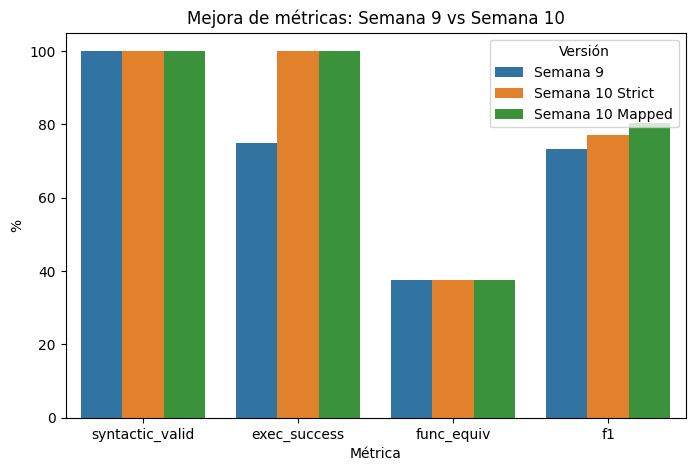

Casos Semana 9: 8
Casos Semana 10 Strict: 8
Casos Semana 10 Mapped: 8


In [14]:
# Comparación de métricas principales: Semana 9 vs Semana 10 (strict y mapped)
import json, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

# Rutas de los resultados
sem9_path = Path('..') / 'results' / 'eval_result.json'
strict_path = Path('..') / 'results' / 'eval_result_strict.json'
mapped_path = Path('..') / 'results' / 'eval_result_mapped.json'

if sem9_path.exists() and strict_path.exists() and mapped_path.exists():
    with open(sem9_path, 'r', encoding='utf-8') as f:
        sem9_results = json.load(f)
    with open(strict_path, 'r', encoding='utf-8') as f:
        strict_results = json.load(f)
    with open(mapped_path, 'r', encoding='utf-8') as f:
        mapped_results = json.load(f)
    df_sem9 = pd.DataFrame(sem9_results)
    df_strict = pd.DataFrame(strict_results)
    df_mapped = pd.DataFrame(mapped_results)
    # Métricas principales
    metrics = ['syntactic_valid', 'exec_success', 'func_equiv', 'f1']
    summary = {
        'Semana 9': [df_sem9[m].dropna().mean() * 100 if m in df_sem9 else None for m in metrics],
        'Semana 10 Strict': [df_strict[m].dropna().mean() * 100 if m in df_strict else None for m in metrics],
        'Semana 10 Mapped': [df_mapped[m].dropna().mean() * 100 if m in df_mapped else None for m in metrics],
    }
    summary_df = pd.DataFrame({'Métrica': metrics, **summary})
    display(summary_df)
    # Figura comparativa
    summary_melted = summary_df.melt(id_vars='Métrica', var_name='Versión', value_name='Valor')
    plt.figure(figsize=(8,5))
    sns.barplot(data=summary_melted, x='Métrica', y='Valor', hue='Versión')
    plt.title('Mejora de métricas: Semana 9 vs Semana 10')
    plt.ylabel('%')
    plt.show()
    print(f"Casos Semana 9: {len(df_sem9)}")
    print(f"Casos Semana 10 Strict: {len(df_strict)}")
    print(f"Casos Semana 10 Mapped: {len(df_mapped)}")   
else:
    print('No se encontraron todos los archivos de resultados. Verifica que existan los archivos de Semana 9 y Semana 10.')